# Week 3: Solution

1. Explore the weather data sets from [Meteo Suisse](https://www.meteosuisse.admin.ch/services-et-publications/service/open-data.html).

2. Choose a weather station and download the temperature time series with a time resolution of 10 minutes for the time period 2010-2019.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# We choose the weather station of Sion.
# Notice that we need to specify that the delimiters in the CSV file are `;`.
df = pd.read_csv('https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/sio/ogd-smn_sio_t_historical_2010-2019.csv',delimiter=';')
df.head()

,station_abbr,reference_timestamp,tre200s0,tre005s0,tresurs0,xchills0,ure200s0,tde200s0,pva200s0,prestas0,...,htoauts0,gre000z0,ods000z0,oli000z0,olo000z0,osr000z0,sre000z0,tso005s0,tso010s0,tso020s0
0,SIO,01.01.2010 00:00,1.1,-1.6,-1.2,-1.3,96.9,0.7,6.4,937.0,...,NaN,0,NaN,NaN,NaN,NaN,0.0,0.6,1.0,1.3
1,SIO,01.01.2010 00:10,1.5,-0.5,-0.8,-1.0,94.4,0.7,6.4,936.9,...,NaN,0,NaN,NaN,NaN,NaN,0.0,0.5,1.0,1.3
2,SIO,01.01.2010 00:20,1.3,-0.4,-0.6,-0.7,95.2,0.6,6.4,936.8,...,NaN,0,NaN,NaN,NaN,NaN,0.0,0.5,1.0,1.3
3,SIO,01.01.2010 00:30,1.5,-0.4,-0.6,-0.8,94.4,0.7,6.4,936.7,...,NaN,0,NaN,NaN,NaN,NaN,0.0,0.5,0.9,1.3
4,SIO,01.01.2010 00:40,0.8,-0.6,-0.6,-0.7,97.3,0.4,6.3,936.6,...,NaN,0,NaN,NaN,NaN,NaN,0.0,0.5,0.9,1.3


According to [the documentation](https://data.geo.admin.ch/ch.meteoschweiz.ogd-smn/ogd-smn_meta_parameters.csv), the temperature measurement is in column `tre200s0`. 

In [2]:
df1 = df.loc[:,['reference_timestamp', 'tre200s0']]
df1.head()

,reference_timestamp,tre200s0
0,01.01.2010 00:00,1.1
1,01.01.2010 00:10,1.5
2,01.01.2010 00:20,1.3
3,01.01.2010 00:30,1.5
4,01.01.2010 00:40,0.8


3. Is the time series noisy?

Let us check that on a plot. 
However, ten years of 10-minutes measurements is a lot of data points.
Let us start with 1000 time steps.

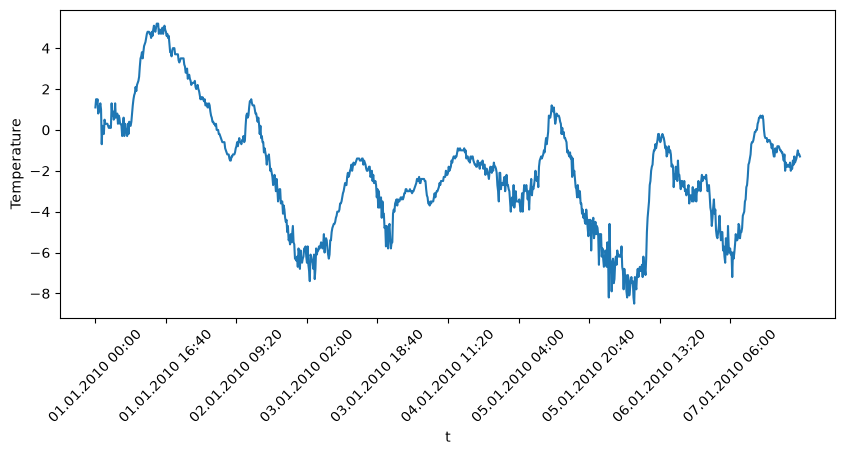

In [3]:
fig,ax = plt.subplots(figsize=(10,4))

ax.plot(df1['reference_timestamp'].iloc[:1000],df1['tre200s0'].iloc[:1000])

ax.set_xlabel('t')
ax.set_ylabel('Temperature')
ax.set_xticks(range(0,1000,100))
ax.tick_params(axis='x', rotation=45) # Reduce the number of x-ticks and rotate the labels for the sake of readability.

plt.show()

The time series is quite noisy.from scipy.signal.windows import get_window


4. Apply a sliding window to smooth the signal.

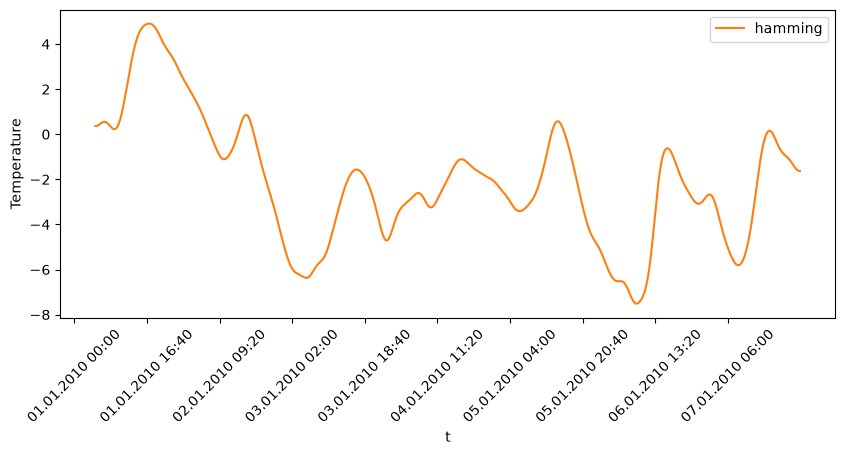

In [4]:
from scipy.signal.windows import get_window

l = 30
win_name = 'hamming'
w = get_window(win_name, l)

df1['windowed'] = df1['tre200s0'].rolling(l).apply(
 lambda x: np.dot(x,w) / w.sum(), raw=True
)

fig,ax = plt.subplots(figsize=(10,4))

ax.plot(df1['reference_timestamp'][:1000], df1['windowed'][:1000], label=win_name, color='C1')

ax.set_xlabel('t')
ax.set_ylabel('Temperature')
ax.legend()

ax.set_xticks(range(0,1000,100))
ax.tick_params(axis='x', rotation=45)

plt.show()

5. What is an appropriate size for the window? Why? Why not more or less?

It depends on the purpose, but in view of the length of the time series, the window can be pretty large. 
Indeed, with a window of length $l=30$, we coven 300 minutes, which is 5 hours. 
Over the course of ten year, the relevant behavior of the temperature is preserved by such a window size. 

A window of just a few steps would be too short as it would not filter enough the noise. 
A window would be too long if it lasted for more than a day, i.e., 120 time steps.

6. Compute and display the ACF for this time series.

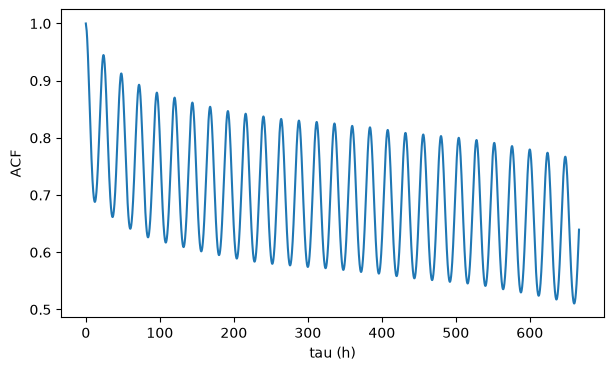

In [5]:
acf_df1 = [df1['tre200s0'].autocorr(lag=tau) for tau in range(0,4000)]

fig, ax = plt.subplots(figsize=(7,4))

ax.plot(np.arange(0,4000)/6, acf_df1)
ax.set_xlabel('tau (h)')
ax.set_ylabel('ACF')

plt.show()

7. What periodicity do you identify?

We observe a daily periodicity (a peak every 120 time steps, 24 hours). 

Let us have a look at longer time lags in an attempt to see yearly periods. 
We skip some lag values in order reduce the numer ov points to display.

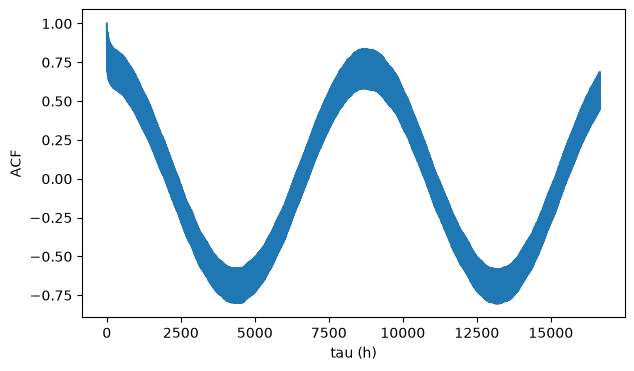

In [6]:
acf_df1 = [df1['tre200s0'].autocorr(lag=tau) for tau in range(0,100000,36)]

fig, ax = plt.subplots(figsize=(7,4))

ax.plot(np.arange(0,100000,36)/6, acf_df1)
ax.set_xlabel('tau (h)')
ax.set_ylabel('ACF')

plt.show()

We clearly see here the combination of the two periodicities: one at 24 hours and one at 365 days.
Both periodic behaviors are clearly identified by the ACF.